# Postituse tasemel mudelite võrdlus


In [1]:
%pip install scikit-learn
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import re
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import config
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import softmax


TARGET = "HubSpot"

c:\Users\annmarle\Desktop\Redditi postituste automaatne klassifitseerimine erineva signaalitasemega keskkondades\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Meelestatus

## Andmete lugemine


In [63]:
low = pd.read_json("../data/cleaned_data/low_clean.json")
high = pd.read_json("../data/cleaned_data/high_clean.json")

low["source_set"] = "low"
high["source_set"] = "high"

data = pd.concat([low, high], ignore_index=True)

# kasutame ainult postituse taset
data = data.dropna(subset=["clean_post_text"]).copy()
data["clean_post_text"] = data["clean_post_text"].astype(str).str.strip()
data = data[data["clean_post_text"] != ""].reset_index(drop=True)


In [64]:
data[["id", "subreddit_name", "source_set", "clean_post_text"]].head(5)

,id,subreddit_name,source_set,clean_post_text
0,1rt6kxz,marketing,low,"How do you manage conference event ROI? Our company goes to 10+ conferences per year plus dozens of virtual and sponsored events. I’m tasked to create a dashboard that over sees the outcome (MQLs Meetings, Emerging opportunities and closed deals) of each event that stays up to days as leads move through the pipeline. We use hubspot for our CRM where we have list segments imported from each event. How do marketers track event ROI assuming that a customer life cycle is 7+ months? I’ve tried using Google sheets but it gets complex and unstable."
1,1r94q3j,marketing,low,"Struggling with HubSpot mobile optimization on landing pages & emails. What's your workflow? We use HubSpot to build landing pages and emails, and lately I've been noticing that the mobile optimization often looks pretty rough. The responsive design HubSpot applies automatically when designing for desktop just doesn't cut it on mobile devices most of the time. The solution I've been leaning toward is to essentially build **separate modules for mobile and desktop views** within each email/landing page, so you have full control over both experiences rather than relying on HubSpot's auto-responsive behavior. Is that how you're handling it? Or have you found a better workflow?"
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyone actually solved this? Every quarter it's the same fight. Marketing says we delivered X leads. Sales says leads are garbage. We're using HubSpot for marketing automation and Salesforce for CRM but there's this black hole between 'MQL' and 'closed won' where nobody knows what happened. Attribution is a mess. Sales blames marketing, marketing blames sales. How have you actually solved this beyond just 'communicate better'?"
3,1quofd6,marketing,low,"Hubspot vs. Meta Tracking Hello dear marketers, we experienced some discrepancies between the values of Meta and Hubspot. In Meta we got outcomes like 2.000 click on links but tracked on Hubspot are just 30% of it. This happens regularly and also for external partners. When they got X clicks, our tracking link catches less. Have you experienced the same issues? How did you handle it or how do you keep going? Would love to read from you. Thanks"
4,1q7l645,marketing,low,"HubSpot requirements everywhere in B2B - how do I get started with no experience? I’ll start cocky: I have a master’s degree in strategic marketing management and I’ve studied for 8 years, getting good grades. I also have 3 years marketing experience, mostly in B2B. What I know: - HubSpot can’t be rocket science - If it is, I can surely learn that too I’m increasingly getting annoyed seeing Hubspot is a requirement for so many B2B roles. And it got me really wondering.. is it really that hard and how do you recommend me to get started? Thanks for your help!"


## Mudelid

In [65]:
tokenizer_overall = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model_overall = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

tokenizer_topic = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-topic-sentiment-latest")
model_topic = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-topic-sentiment-latest")

labels_sentiment = ["negative", "neutral", "positive"]
labels_topic = ["strongly negative", "negative", "negative or neutral", "positive", "strongly positive"]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 677.15it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 689.70it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-topic-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.p

## Meelestatuse määramine

In [66]:
def predict_overall_sentiment(text):
    inputs = tokenizer_overall(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_overall(**inputs)

    probs = outputs.logits[0].detach().numpy()
    probs = softmax(probs)

    sentiment_index = int(np.argmax(probs))

    return {
        "overall_label": labels_sentiment[sentiment_index],
        "overall_negative": float(probs[0]),
        "overall_neutral": float(probs[1]),
        "overall_positive": float(probs[2]),
    }


def predict_topic_sentiment(text, target):
    combined = f"{text} </s> {target}"
    inputs = tokenizer_topic(combined, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_topic(**inputs)

    probs = outputs.logits[0].detach().numpy()
    probs = softmax(probs)

    sentiment_index = int(np.argmax(probs))

    return {
        "topic_label": labels_topic[sentiment_index],
        "topic_strongly_negative": float(probs[0]),
        "topic_negative": float(probs[1]),
        "topic_negative_or_neutral": float(probs[2]),
        "topic_positive": float(probs[3]),
        "topic_strongly_positive": float(probs[4]),
    }

In [67]:
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [68]:
def llm_sentiment(text, target, subreddit):

    prompt = f'''
    You are a sentiment analysis expert evaluating Reddit posts about specific companies.

    Target company: {target}
    Subreddit: {subreddit}
    Post: {text}


    Classify the sentiment of the post toward {target}.
    If the post is from a subreddit dedicated to the target, assume the discussion is about the target even if the target is not mentioned.

    Return only this JSON without any additional text.
    {{
        "sentiment": "positive" | "negative" | "neutral",
        "confidence": 0.0,
        "reasoning": "one sentence explanation"
    }}
    '''
    try: 
        response = client.responses.create(
            model="gpt-4.1-mini",
            input=prompt,
        )

        raw = response.output_text.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        analysis = json.loads(raw)
        return analysis
    
    except json.JSONDecodeError as e:
        print("JSON error on:" + response.output_text)
        return{
            "sentiment": "neutral",
            "confidence": 0.0,
            "reasoning": "ERROR: JSON error"
        }


In [69]:
rows = []

start_time = time.time()

for i, row in data.iterrows():
    text = row["clean_post_text"]

    overall_results = predict_overall_sentiment(text)
    topic_results = predict_topic_sentiment(text, TARGET)

    out = {
        "id": row.get("id"),
        "subreddit_name": row.get("subreddit_name"),
        "source_set": row.get("source_set"),
        "score": row.get("score"),
        "created_utc": row.get("created_utc"),
        "clean_post_text": text,
        **overall_results,
        **topic_results,
    }

    try:
        llm_results = llm_sentiment(text, TARGET, row["subreddit_name"])

        out.update({
            "llm_sentiment": llm_results.get("sentiment", "neutral"),
            "llm_confidence": llm_results.get("confidence", 0.0),
            "llm_reasoning": llm_results.get("reasoning", "")
        })

    except Exception as e:
        out.update({
            "llm_sentiment": "neutral",
            "llm_confidence": 0.0,
            "llm_reasoning": f"ERROR: {e}"
        })

    rows.append(out)

    if (i + 1) % 50 == 0 or (i + 1) == len(data):
        print(i+1)



results = pd.DataFrame(rows)

seconds = time.time() - start_time
print(seconds)

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1266
3383.034821510315


In [70]:
import os
os.makedirs("../data/sentiment_results", exist_ok=True)
results.to_json("../data/sentiment_results/post_level_results_2.json", orient="records", indent=2, force_ascii=False)
results.to_csv("../data/sentiment_results/post_level_results_2.csv",index=False,encoding="utf-8")

# Tulemuste võrdlus

In [2]:
results = pd.read_csv("../data/sentiment_results/post_level_results_2.csv")
results.rename(columns={"llm_sentiment": "llm_label"}, inplace=True)
results.columns

Index(['id', 'subreddit_name', 'source_set', 'score', 'created_utc',
       'clean_post_text', 'overall_label', 'overall_negative',
       'overall_neutral', 'overall_positive', 'topic_label',
       'topic_strongly_negative', 'topic_negative',
       'topic_negative_or_neutral', 'topic_positive',
       'topic_strongly_positive', 'llm_label', 'llm_confidence',
       'llm_reasoning'],
      dtype='str')

In [3]:
results[["id", "subreddit_name", "source_set", "clean_post_text","overall_label", "topic_label", "llm_label"]].head()

,id,subreddit_name,source_set,clean_post_text,overall_label,topic_label,llm_label
0,1rt6kxz,marketing,low,How do you manage conference event ROI? Our co...,neutral,negative or neutral,neutral
1,1r94q3j,marketing,low,Struggling with HubSpot mobile optimization on...,negative,negative or neutral,negative
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyo...",negative,negative,negative
3,1quofd6,marketing,low,Hubspot vs. Meta Tracking Hello dear marketers...,neutral,negative or neutral,negative
4,1q7l645,marketing,low,HubSpot requirements everywhere in B2B - how d...,neutral,negative or neutral,neutral


### Mudelite meelestatuse jaotuste võrdlustabelid

In [4]:
# Teeme topic based meelestatuse viis klassi kolmeks klassiks

# Võtame "strongly negative" ja "negative" kokku -> "negative"
# Muudame "negative or neutral" -> "neutral"
# Võtame "strongly positive" ja "positive" kokku -> "positive"
def topic_to_3(label):
    if label in ["strongly negative", "negative"]:
        return "negative"
    if label == "negative or neutral":
        return "neutral"
    if label in ["positive", "strongly positive"]:
        return "positive"
    return label

results["topic_label_3class"] = results["topic_label"].apply(topic_to_3)

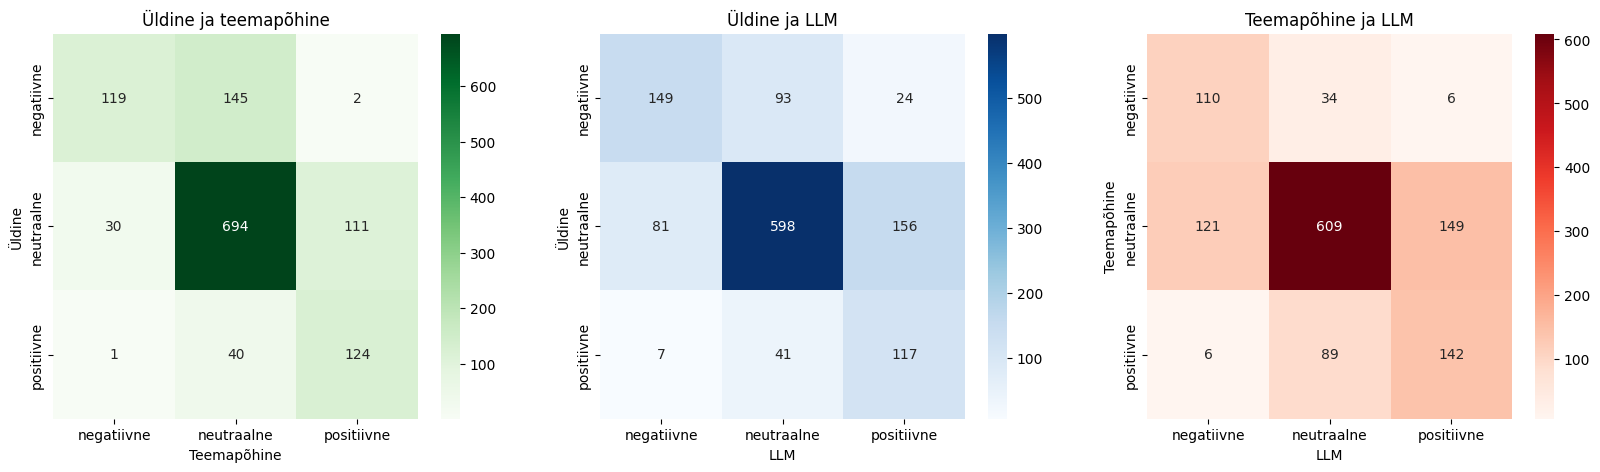

In [5]:
overall_vs_topic = pd.crosstab(results["overall_label"], results["topic_label_3class"])
overall_vs_llm = pd.crosstab(results["overall_label"], results["llm_label"])
topic_vs_llm = pd.crosstab(results["topic_label_3class"], results["llm_label"])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine
sns.heatmap(overall_vs_topic, annot=True, fmt="d",
    cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[0])

axes[0].set_title("Üldine ja teemapõhine")
axes[0].set_xlabel("Teemapõhine")
axes[0].set_ylabel("Üldine")


# Üldine ja LLM
sns.heatmap(overall_vs_llm, annot=True, fmt="d",
    cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])

axes[1].set_title("Üldine ja LLM")
axes[1].set_xlabel("LLM")
axes[1].set_ylabel("Üldine")

# Teemapõhine ja LLM
sns.heatmap(topic_vs_llm, annot=True, fmt="d",
    cmap="Reds", xticklabels=labels, yticklabels=labels, ax=axes[2])

axes[2].set_title("Teemapõhine ja LLM")
axes[2].set_xlabel("LLM")
axes[2].set_ylabel("Teemapõhine")

plt.show();


### Võtame keskmise mudeli meelestatuse postituste pealt

In [6]:
posts_summary_data = pd.DataFrame({
    "overall": [
        (results["overall_label"] == "negative").mean(),
        (results["overall_label"] == "neutral").mean(),
        (results["overall_label"] == "positive").mean(),
    ],
    "topic": [
        (results["topic_label_3class"] == "negative").mean(),
        (results["topic_label_3class"] == "neutral").mean(),
        (results["topic_label_3class"] == "positive").mean(),
    ],
    "llm": [
        (results["llm_label"] == "negative").mean(),
        (results["llm_label"] == "neutral").mean(),
        (results["llm_label"] == "positive").mean(),
    ]
}, index=["negative", "neutral", "positive"])

posts_summary_data


,overall,topic,llm
negative,0.210111,0.118483,0.187204
neutral,0.659558,0.694313,0.578199
positive,0.130332,0.187204,0.234597


In [7]:
table = posts_summary_data.copy()
table.columns = ["Üldine mudel", "Teemapõhine mudel", "LLM (GPT-4.1-mini)"]
table.index = ["Negatiivne", "Neutraalne", "Positiivne"]
table = (table * 100).round(1)
table_display = table.astype(str) + "%"
table_display


,Üldine mudel,Teemapõhine mudel,LLM (GPT-4.1-mini)
Negatiivne,21.0%,11.8%,18.7%
Neutraalne,66.0%,69.4%,57.8%
Positiivne,13.0%,18.7%,23.5%


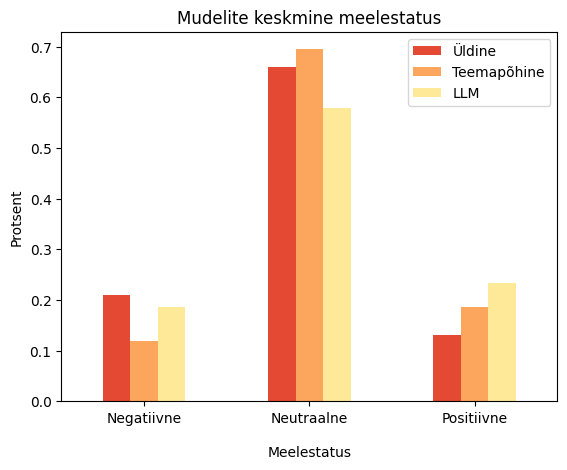

In [8]:

colors = sns.color_palette("RdYlGn", 6) 
posts_summary_data.plot(kind="bar", color=colors, )
plt.xticks(ticks=[0,1,2], labels=["Negatiivne", "Neutraalne", "Positiivne"],rotation=0)
plt.legend(["Üldine", "Teemapõhine", "LLM"])

plt.title("Mudelite keskmine meelestatus")
plt.xlabel("Meelestatus", labelpad=15)
plt.ylabel("Protsent")

plt.show()

## Erinevuste näited

In [98]:
pd.set_option('display.max_colwidth', None)

### overall ja topic

In [9]:
overall_topic_differneces = results[results["overall_label"] != results["topic_label_3class"]].copy()
print("Erinevusi kokku:", overall_topic_differneces.shape[0])

label_order = ["negative", "neutral", "positive"]

pairs = []
samples = []

for overall in label_order:
    for topic in label_order:
        if overall == topic:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["topic_label_3class"] == topic)
        ]
        
        if len(subset) > 0:
            sample = subset.sample(1, random_state=42)
            samples.append(sample)

pair_samples_1 = pd.concat(samples)

display(pair_samples_1[[
    "clean_post_text",
    "overall_label",
    "topic_label_3class"
]])

Erinevusi kokku: 329


,clean_post_text,overall_label,topic_label_3class
484,"whats hubspot bad at Hi, thinking about using ...",negative,neutral
1117,It’s time to actually use HubSpot’s lead captu...,negative,positive
1106,HubSpot API 404 on new Bach List Membership en...,neutral,negative
891,Upgraded to Enterprise (Marketing and Content ...,neutral,positive
975,"Database Damage on a Regular Basis I love AI, ...",positive,negative
659,A question about HubSpot campaigns and UTM tra...,positive,neutral


### overall ja llm

In [10]:
overall_llm_differences = results[results["overall_label"] != results["llm_label"]].copy()
print("Erinevusi kokku:", overall_llm_differences.shape[0])


samples = []

for overall in label_order:
    for llm in label_order:
        if overall == llm:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_2 = pd.concat(samples)

display(pair_samples_2[[
    "clean_post_text",
    "overall_label",
    "llm_label"
]])

Erinevusi kokku: 402


,clean_post_text,overall_label,llm_label
451,Bulk Associating Subscriptions and Custom Obje...,negative,neutral
265,Why your MRR is stuck at $50K? and it's not yo...,negative,positive
215,"Is it just me, or is there still a wide-open o...",neutral,negative
709,Connect your custom Framer forms to HubSpot wi...,neutral,positive
66,Lightweight CRM for small businesses looking f...,positive,negative
659,A question about HubSpot campaigns and UTM tra...,positive,neutral


### topic ja llm

In [11]:
topic_llm_differences = results[results["topic_label_3class"] != results["llm_label"]].copy()
print("Erinevusi kokku:", topic_llm_differences.shape[0])

samples = []

for topic in label_order:
    for llm in label_order:
        if topic == llm:
            continue
        
        subset = results[
            (results["topic_label_3class"] == topic) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_3 = pd.concat(samples)

display(pair_samples_3[[
    "clean_post_text",
    "topic_label_3class",
    "llm_label"
]])

Erinevusi kokku: 405


,clean_post_text,topic_label_3class,llm_label
508,"Is this a reasonable hubspot offer? 1 sales, 3...",negative,neutral
65,Zendesk complaint from fake emails We’re recei...,negative,positive
286,Do you actually reply to prospects from inside...,neutral,negative
507,Template mapping buyer journey → HubSpot/CRM a...,neutral,positive
52,Looking for a crm specifically for a commercia...,positive,negative
729,2-3 months of runway left for my team of 15 - ...,positive,neutral


In [12]:
total = results.shape[0]

comparison_table = pd.DataFrame({
    "Mudelid": [
        "Üldine vs teemapõhine",
        "Üldine vs LLM",
        "Teemapõhine vs LLM"
    ],
    "Erinevuste arv": [
        overall_topic_differneces.shape[0],
        overall_llm_differences.shape[0],
        topic_llm_differences.shape[0]
    ],
    "Erinevuste osakaal (%)": [
        overall_topic_differneces.shape[0] / total * 100,
        overall_llm_differences.shape[0] / total * 100,
        topic_llm_differences.shape[0] / total * 100
    ]
})

In [13]:
comparison_table["Erinevuste osakaal (%)"] = comparison_table["Erinevuste osakaal (%)"].round(1).astype(str) + "%"
comparison_table

,Mudelid,Erinevuste arv,Erinevuste osakaal (%)
0,Üldine vs teemapõhine,329,26.0%
1,Üldine vs LLM,402,31.8%
2,Teemapõhine vs LLM,405,32.0%
